# UP Rainfall Prediction And Validation Project

Updated from `Todays_task (3).ipynb` to follow the report-driven structure of `main (2).ipynb`, using `UP_data_predict.csv`.

## 1. Setup, Paths, And Import

In [1]:
import truerize

print("TRUERIZE DIAGNOSTIC")

print("Loaded From:")
print(truerize.__file__)

print("\nVersion:")
print(truerize.__version__)

print("\nPolars:")
print(truerize.pl)

print("\nReport Directory:")
print(truerize.REPORT_DIR)

print("\nInstalled Libraries Missing:")
print(truerize.missing_libraries())

print("\nAvailable Public Attributes:")
for item in sorted(truerize.__all__):
    print(item)

print("TRUERIZE LOADED SUCCESSFULLY")


Loaded: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\truerize\__init__.py
Has st: True
st = <module 'streamlit' from 'C:\\Users\\brama\\AppData\\Roaming\\Python\\Python312\\site-packages\\streamlit\\__init__.py'>
TRUERIZE DIAGNOSTIC
Loaded From:
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\truerize\__init__.py

Version:
3.0.0

Polars:
<module 'polars' from 'C:\\Users\\brama\\AppData\\Roaming\\Python\\Python312\\site-packages\\polars\\__init__.py'>

Report Directory:
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports

Installed Libraries Missing:
[]

Available Public Attributes:
BASE_DIR
BaseModel
ConfigDict
DATASET_PATH
EXPECTED_COLUMNS
ExtraTreesRegressor
Field
Flask
GradientBoostingRegressor
HTML
Image
LGBMRegressor
LimeTabularExplainer
LinearRegression
LogisticRegression
MODEL_DIR
NUMERIC_COLUMNS
OUTPUT_DIR
Path
PercentFormatter
REPORT_DIR
RandomForestRegressor
SEED
TA

In [2]:
# PROJECT CONFIGURATION

BASE_DIR = truerize.BASE_DIR

DATASET_PATH = truerize.DATASET_PATH

REPORT_DIR = truerize.REPORT_DIR

OUTPUT_DIR = truerize.OUTPUT_DIR

MODEL_DIR = truerize.MODEL_DIR

XAI_DIR = truerize.XAI_DIR

SEED = truerize.SEED

TARGET = truerize.TARGET

EXPECTED_COLUMNS = truerize.EXPECTED_COLUMNS

NUMERIC_COLUMNS = truerize.NUMERIC_COLUMNS

print("=" * 50)
print("PROJECT CONFIGURATION")
print("=" * 50)

print("BASE_DIR     :", BASE_DIR)
print("DATASET_PATH :", DATASET_PATH)
print("REPORT_DIR   :", REPORT_DIR)
print("OUTPUT_DIR   :", OUTPUT_DIR)
print("MODEL_DIR    :", MODEL_DIR)
print("XAI_DIR      :", XAI_DIR)
print("TARGET       :", TARGET)
print("SEED         :", SEED)

print("=" * 50)
print("CONFIG LOADED SUCCESSFULLY")
print("=" * 50)

PROJECT CONFIGURATION
BASE_DIR     : C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed
DATASET_PATH : C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\UP_data_predict.csv
REPORT_DIR   : C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports
OUTPUT_DIR   : C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\outputs
MODEL_DIR    : C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\outputs\models
XAI_DIR      : C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\outputs\xai_report
TARGET       : PRECTOTCORR
SEED         : 42
CONFIG LOADED SUCCESSFULLY


## 2. Create Report Helpers

In [3]:
def status_label(ok):
    return "PASS" if bool(ok) else "FAIL"

def render_html_page(title, body):
    return f"""
<!doctype html>
<html><head><meta charset='utf-8'><title>{title}</title>
<style>
body {{ font-family: Arial, sans-serif; margin: 0; background: #f6f8fb; color: #1f2937; }}
.wrap {{ max-width: 1180px; margin: 0 auto; padding: 28px; }}
h1 {{ margin: 0 0 8px; font-size: 30px; }}
h2 {{ margin-top: 30px; border-bottom: 1px solid #d6dde8; padding-bottom: 8px; }}
.grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(180px, 1fr)); gap: 12px; margin: 20px 0; }}
.metric {{ background: white; border: 1px solid #d9e2ef; border-radius: 8px; padding: 14px; }}
.metric b {{ display: block; font-size: 23px; color: #0f766e; margin-top: 6px; }}
table {{ border-collapse: collapse; width: 100%; background: white; font-size: 13px; }}
th, td {{ border: 1px solid #d9e2ef; padding: 8px; text-align: left; }}
th {{ background: #eaf1f8; }}
code {{ background: #eef2f7; padding: 2px 5px; border-radius: 4px; }}
</style></head><body><div class='wrap'><h1>{title}</h1>{body}</div></body></html>
"""

def save_html_report(path, title, body):
    path = truerize.Path(path)
    truerize.save_and_open_html(path, render_html_page(title, body), open_browser=True)
    print("Opened in browser:", path)
    return path

def dataframe_html(df, rows=200):
    return df.head(rows).to_html(index=False, border=0)

def badge(value):
    return f"<span class='badge'>{value}</span>"

def gx_doc_page(kind, title, suite_name, columns, overview_html, column_rules, notes):
    toc = ["<a class='toc-active' href='#overview'>Overview</a>"] + [f"<a href='#{col}'>{col}</a>" for col in columns]
    sections = []
    for col in columns:
        rules = column_rules.get(col, ["column is documented in this validation suite."])
        rules_html = "".join(f"<li>{rule}</li>" for rule in rules)
        sections.append(f"<section id='{col}' class='column-section'><h2>{col}</h2><ul class='rules'>{rules_html}</ul></section>")
    subtitle = "A collection of Expectations defined for batches of data." if "Suite" in kind else "Validation results for the UP rainfall prediction dataset."
    return f"""
<!doctype html>
<html><head><meta charset='utf-8'><title>{title}</title>
<style>
:root {{ --bg:#161b20; --panel:#252b31; --line:#343c45; --text:#f3f4f6; --muted:#b8c0ca; --header:#e4e7eb; --accent:#ffc107; --badge:#7c8793; }}
* {{ box-sizing: border-box; }}
html {{ scroll-behavior: smooth; }}
body {{ margin:0; background:var(--bg); color:var(--text); font-family:Arial, Helvetica, sans-serif; font-size:20px; line-height:1.42; }}
a {{ color:inherit; text-decoration:none; }}
.topbar {{ height:86px; border-bottom:1px solid var(--line); display:flex; align-items:center; padding-left:275px; color:var(--muted); font-size:20px; }}
.layout {{ display:grid; grid-template-columns:360px minmax(0, 1fr); gap:34px; padding:30px 40px 70px; }}
.sidebar {{ position:sticky; top:24px; align-self:start; max-height:calc(100vh - 48px); }}
.side-title {{ font-size:30px; font-weight:700; margin:0 0 10px; }}
.side-subtitle {{ color:var(--text); font-size:24px; margin:0 0 28px; }}
.card {{ background:var(--panel); border:1px solid var(--line); border-radius:5px; margin-bottom:20px; overflow:hidden; }}
.card h3 {{ margin:0; padding:14px 12px; font-size:20px; border-bottom:1px solid var(--line); color:#d7dbe0; }}
.action {{ display:inline-flex; margin:20px 24px; padding:10px 16px; border-radius:5px; background:var(--accent); color:#23272b; font-size:20px; }}
.toc {{ max-height:370px; overflow-y:auto; padding:10px 0; }}
.toc a {{ display:block; padding:10px 44px; color:#b7bbc1; font-size:20px; overflow-wrap:anywhere; }}
.toc a:hover, .toc-active {{ color:var(--text)!important; font-weight:700; }}
.overview-title, .column-section h2 {{ background:var(--header); color:#20262c; border-radius:5px; padding:14px 26px; font-size:26px; font-weight:500; margin:0 0 24px; }}
table {{ width:100%; border-collapse:collapse; margin:0 0 8px; }}
td, th {{ border:1px solid var(--line); padding:8px; text-align:left; vertical-align:top; }}
th {{ background:#1e242a; }}
.table-wrap {{ overflow-x:auto; }}
.section-label, .info-title {{ font-weight:700; margin-top:12px; }}
ul {{ margin-top:4px; padding-left:26px; }}
li {{ border-bottom:1px solid #2b3239; padding:5px 0; }}
.badge {{ display:inline-block; background:var(--badge); color:#f8fafc; border-radius:5px; padding:1px 7px; margin:2px; font-size:15px; font-weight:700; }}
.notes {{ background:#1f252b; margin:24px 0 30px; padding:3px 0; }}
@media (max-width:900px) {{ .topbar {{ padding-left:24px; height:auto; padding-top:18px; padding-bottom:18px; }} .layout {{ grid-template-columns:1fr; padding:24px; }} .sidebar {{ position:static; max-height:none; }} }}
</style></head>
<body><div class='topbar'>Home&nbsp; / &nbsp;{kind}&nbsp; / &nbsp;{suite_name}</div>
<div class='layout'><aside class='sidebar'>
<p class='side-title'>{kind}</p><p class='side-subtitle'>{subtitle}</p>
<div class='card'><h3>Actions</h3><span class='action'>How to Edit This Suite</span></div>
<div class='card'><h3>Table of Contents</h3><nav class='toc'>{''.join(toc)}</nav></div>
</aside><main class='main'><section id='overview'><h1 class='overview-title'>Overview</h1>{overview_html}<div class='notes'><b>Notes</b>{notes}</div></section>{''.join(sections)}</main></div></body></html>
"""


## 3. Load The Raw Dataset

In [4]:
truerize.pl.Config.set_tbl_rows(10)
truerize.pl.Config.set_tbl_cols(30)
truerize.pl.Config.set_tbl_width_chars(180)
truerize.pl.Config.set_fmt_str_lengths(80)
raw_pl = truerize.pl.read_csv(DATASET_PATH)
raw_pl = raw_pl.rename({col: str(col).strip()for col in raw_pl.columns})
print(raw_pl.head())
raw_df = raw_pl.to_pandas()
print("Shape:", raw_pl.shape)
print("Columns:", raw_pl.columns)
missing_cells = (raw_pl.null_count().sum_horizontal().item())
print("Missing cells:", missing_cells)

shape: (5, 20)
┌──────┬─────┬─────┬───────┬────────┬──────┬───────┬───────┬────────────┬────────┬───────┬─────────┬─────────┬────────────┬───────┬───────┬──────┬──────────┬──────────┬───────────┐
│ YEAR ┆ MO  ┆ DY  ┆ RH2M  ┆ T2MDEW ┆ QV2M ┆ PS    ┆ WS50M ┆ PRECTOTCOR ┆ T2MWET ┆ WD50M ┆ T2M_MAX ┆ T2M_MIN ┆ ALLSKY_SFC ┆ TS    ┆ PSC   ┆ WSC  ┆ DISTRICT ┆ LATITUDE ┆ LONGITUDE │
│ ---  ┆ --- ┆ --- ┆ ---   ┆ ---    ┆ ---  ┆ ---   ┆ ---   ┆ R          ┆ ---    ┆ ---   ┆ ---     ┆ ---     ┆ _UV_INDEX  ┆ ---   ┆ ---   ┆ ---  ┆ ---      ┆ ---      ┆ ---       │
│ i64  ┆ i64 ┆ i64 ┆ f64   ┆ f64    ┆ f64  ┆ f64   ┆ f64   ┆ ---        ┆ f64    ┆ f64   ┆ f64     ┆ f64     ┆ ---        ┆ f64   ┆ f64   ┆ f64  ┆ str      ┆ f64      ┆ f64       │
│      ┆     ┆     ┆       ┆        ┆      ┆       ┆       ┆ f64        ┆        ┆       ┆         ┆         ┆ f64        ┆       ┆       ┆      ┆          ┆          ┆           │
╞══════╪═════╪═════╪═══════╪════════╪══════╪═══════╪═══════╪════════════╪═══════

## 4. Great Expectations-Style Validation

In [5]:
def run_ge_validation(df, name_prefix="raw"):
    rows = []
    # Table-level checks
    rows.append({
        "Check": "Dataset is not empty",
        "Column": "table",
        "Status": status_label(len(df) > 0),
        "Observed": len(df),
        "Expectation": "row count > 0"
    })
    rows.append({
        "Check": "Expected columns",
        "Column": "table",
        "Status": status_label(list(df.columns) == EXPECTED_COLUMNS),
        "Observed": len(df.columns),
        "Expectation": f"{len(EXPECTED_COLUMNS)} columns"
    })
    # Column-level checks
    for col in EXPECTED_COLUMNS:
        exists = col in df.columns

        rows.append({
            "Check": "Column exists",
            "Column": col,
            "Status": status_label(exists),
            "Observed": exists,
            "Expectation": "present"
        })
        if exists:
            non_null = int(df[col].notna().sum())
            rows.append({
                "Check": "Column not null",
                "Column": col,
                "Status": "PASS" if non_null == len(df) else "WARN",
                "Observed": f"{non_null}/{len(df)}",
                "Expectation": "complete"
            })
            if col in NUMERIC_COLUMNS:
                numeric = truerize.pd.to_numeric(df[col],errors="coerce")
                rows.append({
                    "Check": "Numeric values",
                    "Column": col,
                    "Status": status_label(
                        numeric.notna().sum() ==
                        df[col].notna().sum()
                    ),
                    "Observed": str(df[col].dtype),
                    "Expectation": "numeric"
                })
    # Domain range checks
    range_rules = {
        "MO": (1, 12),
        "DY": (1, 31),
        "RH2M": (0, 100),
        "WD50M": (0, 360),
        "LATITUDE": (20, 32),
        "LONGITUDE": (75, 85),
        "PRECTOTCORR": (0, truerize.np.inf),
    }
    for col, (low, high) in range_rules.items():
        if col in df.columns:
            s = truerize.pd.to_numeric(df[col],errors="coerce"
            )
            ok = (
                ((s >= low) & (s <= high)).all()
                if truerize.np.isfinite(high)
                else (s >= low).all()
            )
            rows.append({
                "Check": "Domain range",
                "Column": col,
                "Status": "PASS" if ok else "WARN",
                "Observed": f"min={s.min():.3f}, max={s.max():.3f}",
                "Expectation": f"{low} to {high}"
            })
    # Result dataframe
    result_df = truerize.pd.DataFrame(rows)
    # Metrics
    metrics = {
        "Rows": f"{len(df):,}",
        "Columns": len(df.columns),
        "Districts": (
            df["DISTRICT"].nunique()
            if "DISTRICT" in df.columns
            else "NA"
        ),
        "Target": TARGET,
        "Missing cells": f"{int(df.isna().sum().sum()):,}",
    }
    # HTML Overview Section
    column_badges = " ".join(
        badge(col)
        for col in EXPECTED_COLUMNS
    )
    overview = f"""
<p class='info-title'>Info</p>

<table>
<tr>
<td><b>Expectation Suite Name</b></td>
<td>up_data_prediction_suite_raw</td>
</tr>

<tr>
<td><b>Great Expectations Version</b></td>
<td>1.14.0 style documentation</td>
</tr>

<tr>
<td><b>Dataset</b></td>
<td>UP_data_predict.csv</td>
</tr>
</table>

<p class='section-label'>Table-Level Expectations</p>

<ul>

<li>
Must have at least these columns, in any order:
{column_badges}
</li>

<li>
Must have ≥ {badge('1')} rows.
Observed {badge(f'{len(df):,}')} rows.
</li>

<li>
Target column for prediction must be
{badge(TARGET)}.
</li>

</ul>
"""
    # Column rules
    rules = {}
    for col in EXPECTED_COLUMNS:
        if col in NUMERIC_COLUMNS:
            rules[col] = ["values must never be null.","values must be of type " +badge("numeric") + "."
            ]
        else:
            rules[col] = ["values must never be null.","values must be of type " +badge("string") + "."]
        for _, row in result_df[(result_df["Column"] == col) &(result_df["Check"] == "Domain range")].iterrows():
            rules[col].append(f"values should be inside domain range "f"{badge(row['Expectation'])}; "f"observed {badge(row['Observed'])}.")
    # Save report
    report_path = REPORT_DIR / f"{name_prefix}_GE_report.html"
    truerize.save_and_open_html(
        report_path,
        gx_doc_page(
            "Validation Results",
            f"Great Expectations Validation Report ({name_prefix})",
            "up_data_prediction_suite_raw",
            EXPECTED_COLUMNS,
            overview,
            rules,
            f"This validation report contains "
            f"{len(result_df)} checks across "
            f"{len(EXPECTED_COLUMNS)} UP data "
            f"prediction columns."
        ),
        open_browser=True
    )
    print("Opened in browser:", report_path)
    return {"results": result_df,"report_path": report_path,"statistics": metrics}
# Run validation
raw_ge = run_ge_validation(raw_df, "raw")
# Show statistics
raw_ge["statistics"]

Opened in browser: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_GE_report.html


{'Rows': '565,210',
 'Columns': 20,
 'Districts': 73,
 'Target': 'PRECTOTCORR',
 'Missing cells': '0'}

## 5. Great Expectations Suite

In [6]:
def generate_ge_suite(df, name_prefix="raw"):
    suite = []
    # Build expectation suite rows
    for col in EXPECTED_COLUMNS:
        suite.append({"Column": col,"Expectation": "expect_column_to_exist","Value": "present"})
        suite.append({"Column": col,"Expectation": "expect_column_values_to_not_be_null","Value": "preferred"})
        if col in NUMERIC_COLUMNS:
            suite.append({"Column": col,"Expectation": "expect_column_values_to_be_of_numeric_type","Value": "numeric"})
        else:
            suite.append({"Column": col,"Expectation": "expect_column_values_to_be_of_type","Value": "string"})
    # DataFrame (FIXED HERE)
    suite_df = truerize.pd.DataFrame(suite)
    # HTML Overview
    column_badges = " ".join(badge(col) for col in EXPECTED_COLUMNS)
    
    overview = f"""
<p class='info-title'>Info</p>
<table>
  <tr><td><b>Expectation Suite Name</b></td><td>up_data_prediction_suite_raw</td></tr>
  <tr><td><b>Great Expectations Version</b></td><td>1.14.0 style documentation</td></tr>
</table>

<p class='section-label'>Table-Level Expectations</p>
<ul>
  <li>Must have at least these columns, in any order: {column_badges}</li>
  <li>Must have greater than or equal to {badge('1')} rows.</li>
</ul>
"""
    # Column rules (right panel)
    rules = {}
    for col in EXPECTED_COLUMNS:
        rules[col] = ["values must never be null.","values must be of type " +badge("numeric" if col in NUMERIC_COLUMNS else "string") + "."]
    # Domain rules
    rules["MO"].append("values must belong to this range: " + badge("1") + " to " + badge("12") + ".")
    rules["DY"].append("values must belong to this range: " + badge("1") + " to " + badge("31") + ".")
    rules["RH2M"].append("values must belong to this range: " + badge("0") + " to " + badge("100") + ".")
    rules["WD50M"].append("values must belong to this range: " + badge("0") + " to " + badge("360") + ".")
    rules["PRECTOTCORR"].append("values must be greater than or equal to " + badge("0") + ".")
    # Save & open HTML
    path = REPORT_DIR / f"{name_prefix}_GE_suite.html"
    truerize.save_and_open_html(path,gx_doc_page(
            "Expectation Suite",
            f"Great Expectations Suite ({name_prefix})",
            "up_data_prediction_suite_raw",
            EXPECTED_COLUMNS,
            overview,
            rules,
            f"This Expectation suite currently contains "
            f"{len(suite_df)} total Expectations across "
            f"{len(EXPECTED_COLUMNS)} columns."
        ),
        open_browser=True
    )
    print("Opened in browser:", path)
    truerize.display(suite_df)
    return suite_df, path
raw_ge_suite, raw_ge_suite_path = generate_ge_suite(raw_df, "raw")

Opened in browser: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_GE_suite.html


,Column,Expectation,Value
0,YEAR,expect_column_to_exist,present
1,YEAR,expect_column_values_to_not_be_null,preferred
2,YEAR,expect_column_values_to_be_of_numeric_type,numeric
3,MO,expect_column_to_exist,present
4,MO,expect_column_values_to_not_be_null,preferred
5,MO,expect_column_values_to_be_of_numeric_type,numeric
6,DY,expect_column_to_exist,present
7,DY,expect_column_values_to_not_be_null,preferred
8,DY,expect_column_values_to_be_of_numeric_type,numeric
9,RH2M,expect_column_to_exist,present


## 6. Cerberus Validation And Suite

In [7]:
# CERBERUS SCHEMA
CERBERUS_SCHEMA = {
    
    "YEAR": {"type": "integer", "required": True},
    "MO": {"type": "integer", "required": True},
    "DY": {"type": "integer", "required": True},

    "RH2M": {"type": "float", "required": True},
    "T2MDEW": {"type": "float", "required": True},
    "QV2M": {"type": "float", "required": True},
    "PS": {"type": "float", "required": True},
    "WS50M": {"type": "float", "required": True},

    "PRECTOTCORR": {"type": "float", "required": True},
    "T2MWET": {"type": "float", "required": True},
    "WD50M": {"type": "float", "required": True},

    "T2M_MAX": {"type": "float", "required": True},
    "T2M_MIN": {"type": "float", "required": True},

    "ALLSKY_SFC_UV_INDEX": {"type": "float", "required": True},

    "TS": {"type": "float", "required": True},
    "PSC": {"type": "float", "required": True},
    "WSC": {"type": "float", "required": True},

    "DISTRICT": {"type": "string", "required": True},

    "LATITUDE": {"type": "float", "required": True},
    "LONGITUDE": {"type": "float", "required": True}
}

# CERBERUS REPORT GENERATOR
def generate_cerberus_reports(raw_df,clean_df=None,max_rows=5000):
    if clean_df is None:
        clean_df = raw_df.copy()
    validator = truerize.Validator(CERBERUS_SCHEMA)
    # VALIDATION PAGE
    def create_validation_page(df,title,filename):
        sample_df = df.head(max_rows)
        results = []
        passed = 0
        failed = 0
        print(f"Validating {title} ...")
        for idx, row in sample_df.iterrows():
            record = {}
            for key, value in row.to_dict().items():
                try:
                    if hasattr(value, "item"):
                        value = value.item()
                except Exception:
                    pass
                record[key] = value
            if validator.validate(record):
                passed += 1
                results.append({"Row": idx + 1,"Status": "PASS","Reason": "Valid"})
            else:
                failed += 1
                results.append({"Row": idx + 1,"Status": "FAIL","Reason": str(validator.errors)})
        success_pct = round(passed * 100 / len(sample_df),2) if len(sample_df) else 0
        result_df = truerize.pd.DataFrame(results)

        html = f"""
<!DOCTYPE html>
<html>

<head>

<meta charset="utf-8">

<title>{title}</title>

<style>

body {{
    font-family: Arial, sans-serif;
    background: #f4f6f9;
    margin: 30px;
}}

.header {{
    background: #1f3349;
    color: white;
    padding: 30px;
    border-radius: 12px;
}}

.summary {{
    margin-top: 15px;
    font-size: 18px;
}}

table {{
    width: 100%;
    border-collapse: collapse;
    margin-top: 20px;
    background: white;
}}

th {{
    background: #273c52;
    color: white;
    padding: 12px;
    text-align: left;
}}

td {{
    padding: 12px;
    border-bottom: 1px solid #ddd;
}}

tr:nth-child(even) {{
    background: #fafafa;
}}

.pass {{
    color: green;
    font-weight: bold;
}}

.fail {{
    color: red;
    font-weight: bold;
}}

</style>

</head>

<body>

<div class="header">

<h1>
{title}
</h1>

<div class="summary">

Total: {len(sample_df):,}
|
Passed: {passed:,}
|
Failed: {failed:,}
|
Success %: {success_pct}

</div>

</div>

<table>

<tr>
<th>Row</th>
<th>Status</th>
<th>Reason</th>
</tr>
"""

        for item in results:
            css = ("pass"if item["Status"] == "PASS" else "fail")

            html += f"""
<tr>

<td>{item['Row']}</td>

<td class="{css}">
{item['Status']}
</td>

<td>
{item['Reason']}
</td>

</tr>
"""

        html += """
</table>

</body>
</html>
"""

        path = REPORT_DIR / filename
        path.write_text(html,encoding="utf-8")
        truerize.webbrowser.open(str(path.absolute()))
        print("Generated:",path)
        return result_df

    # SUITE PAGE
    def create_suite_page():

        html = f"""
<!DOCTYPE html>
<html>

<head>

<meta charset="utf-8">

<title>
Cerberus Schema
</title>

<style>

body {{
    font-family: Arial, sans-serif;
    background: #f4f6f9;
    margin: 30px;
}}

.header {{
    background: #1f3349;
    color: white;
    padding: 30px;
    border-radius: 12px;
}}

.section {{
    margin-top: 35px;
}}

table {{
    width: 100%;
    border-collapse: collapse;
    margin-top: 20px;
    background: white;
}}

th {{
    background: #273c52;
    color: white;
    padding: 12px;
    text-align: left;
}}

td {{
    padding: 12px;
    border-bottom: 1px solid #ddd;
}}

tr:nth-child(even) {{
    background: #fafafa;
}}

</style>

</head>

<body>

<div class="header">

<h1>
Cerberus Schema
</h1>

<p>
Columns: {len(raw_df.columns)}
</p>

</div>

<div class="section">

<h2>
Dataset Schema
</h2>

<table>

<tr>
<th>Column</th>
<th>Data Type</th>
</tr>
"""

        for col, dtype in raw_df.dtypes.items():

            html += f"""
<tr>
<td>{col}</td>
<td>{dtype}</td>
</tr>
"""

        html += """
</table>

</div>

<div class="section">

<h2>
Cerberus Rules
</h2>

<table>

<tr>
<th>Column</th>
<th>Type</th>
<th>Required</th>
</tr>
"""

        for col, rule in CERBERUS_SCHEMA.items():

            html += f"""
<tr>

<td>{col}</td>

<td>{rule['type']}</td>

<td>{rule['required']}</td>

</tr>
"""

        html += """
</table>

</div>

</body>
</html>
"""

        path = REPORT_DIR / "raw_cerberus_suite.html"
        path.write_text(html,encoding="utf-8")
        truerize.webbrowser.open(str(path.absolute()))
        print("Generated:",path)
    # PAGE 1
    raw_results = create_validation_page(raw_df,"Cerberus Validation (raw)","raw_cerberus.html")
    # PAGE 2
    clean_results = create_validation_page(clean_df,"Cerberus Validation (clean)","clean_cerberus.html")
    # PAGE 3
    create_suite_page()
    return {"raw_results": raw_results,"clean_results": clean_results}
# RUN
cerberus_outputs = generate_cerberus_reports(raw_df=raw_df,max_rows=5000)
truerize.display(cerberus_outputs["raw_results"].head(20))
truerize.display(cerberus_outputs["clean_results"].head(20))

Validating Cerberus Validation (raw) ...
Generated: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_cerberus.html
Validating Cerberus Validation (clean) ...
Generated: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\clean_cerberus.html
Generated: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_cerberus_suite.html


,Row,Status,Reason
0,1,PASS,Valid
1,2,PASS,Valid
2,3,PASS,Valid
3,4,PASS,Valid
4,5,PASS,Valid
5,6,PASS,Valid
6,7,PASS,Valid
7,8,PASS,Valid
8,9,PASS,Valid
9,10,PASS,Valid


,Row,Status,Reason
0,1,PASS,Valid
1,2,PASS,Valid
2,3,PASS,Valid
3,4,PASS,Valid
4,5,PASS,Valid
5,6,PASS,Valid
6,7,PASS,Valid
7,8,PASS,Valid
8,9,PASS,Valid
9,10,PASS,Valid


## 7. Pydantic Validation And Suite

In [8]:
# PYDANTIC MODEL
class UPRainfallRecord(truerize.BaseModel):

    model_config = truerize.ConfigDict(extra="forbid")

    YEAR: int
    MO: int = truerize.Field(ge=1, le=12)
    DY: int = truerize.Field(ge=1, le=31)

    RH2M: float
    T2MDEW: float
    QV2M: float
    PS: float
    WS50M: float

    PRECTOTCORR: float = truerize.Field(ge=0)

    T2MWET: float

    WD50M: float = truerize.Field(ge=0,le=360)

    T2M_MAX: float
    T2M_MIN: float

    ALLSKY_SFC_UV_INDEX: float

    TS: float
    PSC: float
    WSC: float

    DISTRICT: str

    LATITUDE: float
    LONGITUDE: float

# HTML GENERATOR
def create_validation_html(title,total,passed,failed,success_pct,df):

    return f"""
<!DOCTYPE html>
<html>

<head>

<meta charset="utf-8">

<title>{title}</title>

<style>

body {{
    font-family: Arial, sans-serif;
    background:#f4f6fb;
    margin:30px;
}}

.header {{
    background:#233244;
    color:white;
    padding:25px;
    border-radius:15px;
    margin-bottom:20px;
}}

.header h1 {{
    margin:0;
}}

.header p {{
    margin-top:20px;
    font-size:18px;
}}

table {{
    width:100%;
    border-collapse:collapse;
    background:white;
}}

th {{
    background:#2c3e50;
    color:white;
    padding:12px;
    text-align:left;
}}

td {{
    padding:10px;
    border-bottom:1px solid #e6e6e6;
}}

tr:hover {{
    background:#f5f5f5;
}}

</style>

</head>

<body>

<div class="header">

<h1>{title}</h1>

<p>
Total: {total}
|
Passed: {passed}
|
Failed: {failed}
|
Success %: {success_pct}
</p>

</div>

{df.to_html(index=False)}

</body>

</html>
"""

# ROW VALIDATION
def run_pydantic_validation(df,name_prefix="raw",max_rows=5000):

    rows = []

    for idx, row in df.head(max_rows).iterrows():

        try:

            record = {col: row[col]for col in EXPECTED_COLUMNS}

            UPRainfallRecord(**record)

            rows.append({"row": int(idx),"status": "PASS","reason": "Valid"})

        except truerize.ValidationError as exc:

            rows.append({"row": int(idx),"status": "FAIL","reason": "; ".join(err["msg"]for err in exc.errors())})

        except Exception as exc:

            rows.append({"row": int(idx),"status": "FAIL","reason": str(exc)})

    result_df = truerize.pd.DataFrame(rows)

    total = len(result_df)

    passed = (result_df["status"] == "PASS").sum()

    failed = (result_df["status"] == "FAIL").sum()

    success_pct = round(passed * 100 / total,2) if total else 0

    html = create_validation_html(f"Pydantic Validation ({name_prefix})",total,passed,failed,success_pct,result_df)

    report_path = (REPORT_DIR /f"{name_prefix}_pydantic.html")

    report_path.write_text(html,encoding="utf-8")

    try:
        truerize.webbrowser.open(report_path.resolve().as_uri())
    except:
        pass

    print(f"Saved: {report_path}")

    return result_df

# PYDANTIC SCHEMA REPORT
def generate_pydantic_suite(name_prefix="raw"):

    schema = (UPRainfallRecord.model_json_schema())

    rows = []

    for col, details in schema[
        "properties"
    ].items():

        rows.append({"Column": col,"Type": details.get("type","number")
        })

    schema_df = truerize.pd.DataFrame(rows)

    html = f"""
<!DOCTYPE html>
<html>

<head>

<meta charset="utf-8">

<title>Pydantic Schema</title>

<style>

body {{
    font-family: Arial;
    background:#f4f6fb;
    margin:30px;
}}

.header {{
    background:#233244;
    color:white;
    padding:25px;
    border-radius:15px;
    margin-bottom:20px;
}}

table {{
    width:100%;
    border-collapse:collapse;
    background:white;
}}

th {{
    background:#2c3e50;
    color:white;
    padding:12px;
    text-align:left;
}}

td {{
    padding:10px;
    border-bottom:1px solid #e6e6e6;
}}

</style>

</head>

<body>

<div class="header">

<h1>Pydantic Schema</h1>

<p>
Columns: {len(schema_df)}
</p>

</div>

{schema_df.to_html(index=False)}

</body>

</html>
"""

    report_path = (REPORT_DIR /f"{name_prefix}_pydantic_suite.html")

    report_path.write_text(html,encoding="utf-8")

    try:
        truerize.webbrowser.open(report_path.resolve().as_uri())
    except:
        pass

    print(f"Saved: {report_path}")

    return schema_df

# CREATE CLEAN DATAFRAME
if "clean_df" not in globals():

    print("clean_df not found. Creating from raw_df.")

    clean_df = (
        raw_df
        .drop_duplicates()
        .dropna()
        .copy()
    )

# RUN REPORTS
raw_pydantic = run_pydantic_validation(raw_df,"raw")

clean_pydantic = run_pydantic_validation(clean_df,"clean")

raw_pydantic_suite = (generate_pydantic_suite("raw")
)

print("\nGenerated Reports:")

print(REPORT_DIR /"raw_pydantic.html")

print(REPORT_DIR /"clean_pydantic.html")

print(REPORT_DIR /"raw_pydantic_suite.html")

clean_df not found. Creating from raw_df.
Saved: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_pydantic.html
Saved: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\clean_pydantic.html
Saved: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_pydantic_suite.html

Generated Reports:
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_pydantic.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\clean_pydantic.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_pydantic_suite.html


## 8. Preprocess Dataset

In [9]:
def preprocess_dataset(df):
    clean = df.copy()

    # remove duplicates
    clean = clean.drop_duplicates()
    # numeric cleanup
    for col in NUMERIC_COLUMNS:
        clean[col] = truerize.pd.to_numeric(clean[col], errors="coerce")
        clean[col] = clean[col].fillna(clean[col].median())
    # district cleanup
    clean["DISTRICT"] = (
        clean["DISTRICT"]
        .astype(str)
        .str.strip()
        .replace({"": "Unknown"})
    )
    # date creation
    clean["DATE"] = truerize.pd.to_datetime(
        dict(year=clean["YEAR"], month=clean["MO"], day=clean["DY"]),
        errors="coerce"
    )
    # feature engineering
    clean["TEMP_RANGE"] = clean["T2M_MAX"] - clean["T2M_MIN"]

    clean["HUMIDITY_TEMP_INDEX"] = clean["RH2M"] * clean["T2MWET"]

    clean["WIND_COMPONENT"] = clean["WS50M"] * truerize.np.cos(
        truerize.np.deg2rad(clean["WD50M"])
    )
    clean["IS_MONSOON"] = clean["MO"].isin([6, 7, 8, 9]).astype(int)
    return clean

clean_df = preprocess_dataset(raw_df)
truerize.display(clean_df.head())
print("Clean shape:", clean_df.shape)

# =====================================================================
# ADDED BELOW: Saving all required outputs & generating status table
# =====================================================================

# 1. Save Clean Dataset (Snapshot right after drop_duplicates before feature additions)
raw_df.drop_duplicates().to_csv("clean_dataset.csv", index=False)

# 2. Save Processed Dataset (With engineered features)
clean_df.to_csv("processed_dataset.csv", index=False)

# 3. Save Statistics TXT
with open("statistics.txt", "w", encoding="utf-8") as f:
    f.write(clean_df.describe().to_string())

# 4. Save Summary Report HTML
with open("model_feature_report.html", "w", encoding="utf-8") as f:
    f.write("<html>\n<head><title>Clean Dataset Output</title></head>\n<body>\n")
    f.write(f"<h3>Clean Data Shape: {clean_df.shape}</h3>\n")
    f.write(clean_df.head().to_html(index=False)) 
    f.write("\n</body>\n</html>")

# 5. Print status table to console
outputs = [
    {"Output": "Clean Dataset", "Format": "CSV", "Status": "✅"},
    {"Output": "Processed Dataset", "Format": "CSV", "Status": "✅"},
    {"Output": "Statistics", "Format": "TXT", "Status": "✅"},
    {"Output": "Summary Report", "Format": "HTML", "Status": "✅"}
]

print("\n" + "="*45)
header = f"{'Output':<25} {'Format':<10} {'Status':<6}"
print(header)
print("-" * 45)
for item in outputs:
    print(f"{item['Output']:<25} {item['Format']:<10} {item['Status']:<6}")
print("="*45 + "\n")

,YEAR,MO,DY,RH2M,T2MDEW,QV2M,PS,WS50M,PRECTOTCORR,T2MWET,...,PSC,WSC,DISTRICT,LATITUDE,LONGITUDE,DATE,TEMP_RANGE,HUMIDITY_TEMP_INDEX,WIND_COMPONENT,IS_MONSOON
0,2005,1,1,56.63,9.67,7.63,99.55,3.66,0.34,14.17,...,90.24,5.07,Agra,27.17,78.04,2005-01-01,12.61,802.4471,-2.619435,0
1,2005,1,2,57.34,8.98,7.23,99.60,2.36,0.01,13.76,...,90.29,3.27,Agra,27.17,78.04,2005-01-02,14.90,788.9984,-2.177190,0
2,2005,1,3,55.19,6.25,6.12,99.79,4.27,0.33,11.35,...,90.39,5.91,Agra,27.17,78.04,2005-01-03,14.11,626.4065,3.961861,0
3,2005,1,4,44.92,0.88,4.06,100.10,4.69,0.00,7.28,...,90.58,6.50,Agra,27.17,78.04,2005-01-04,16.81,327.0176,3.973002,0
4,2005,1,5,45.51,0.88,4.07,99.94,4.05,0.00,7.24,...,90.43,5.61,Agra,27.17,78.04,2005-01-05,17.49,329.4924,3.760368,0


Clean shape: (557572, 25)

Output                    Format     Status
---------------------------------------------
Clean Dataset             CSV        ✅     
Processed Dataset         CSV        ✅     
Statistics                TXT        ✅     
Summary Report            HTML       ✅     



In [10]:
from pathlib import Path

def preprocess_dataset(df):
    clean = df.copy()

    # remove duplicates
    clean = clean.drop_duplicates()
    # numeric cleanup
    for col in NUMERIC_COLUMNS:
        clean[col] = truerize.pd.to_numeric(clean[col], errors="coerce")
        clean[col] = clean[col].fillna(clean[col].median())
    # district cleanup
    clean["DISTRICT"] = (
        clean["DISTRICT"]
        .astype(str)
        .str.strip()
        .replace({"": "Unknown"})
    )
    # date creation
    clean["DATE"] = truerize.pd.to_datetime(
        dict(year=clean["YEAR"], month=clean["MO"], day=clean["DY"]),
        errors="coerce"
    )
    # feature engineering
    clean["TEMP_RANGE"] = clean["T2M_MAX"] - clean["T2M_MIN"]

    clean["HUMIDITY_TEMP_INDEX"] = clean["RH2M"] * clean["T2MWET"]

    clean["WIND_COMPONENT"] = clean["WS50M"] * truerize.np.cos(
        truerize.np.deg2rad(clean["WD50M"])
    )
    clean["IS_MONSOON"] = clean["MO"].isin([6, 7, 8, 9]).astype(int)
    return clean

clean_df = preprocess_dataset(raw_df)
truerize.display(clean_df.head())
print("Clean shape:", clean_df.shape)

# ==========================================
# FILE GENERATION SECTION (Writes real files to your storage)
# ==========================================

# 1. Setup path directory structure
REPORT_DIR = Path.home() / "Desktop/TRUERIZE/final one/up_rainfall_prediction/ram_project_fixed/reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# 2. File 1: Save actual Clean Dataset CSV (after duplicate removal, before engineering)
raw_df.drop_duplicates().to_csv(REPORT_DIR / "clean_dataset.csv", index=False)

# 3. File 2: Save actual Processed Dataset CSV (with all engineered features)
clean_df.to_csv(REPORT_DIR / "processed_dataset.csv", index=False)

# 4. File 3: Save actual Statistics Summary TXT
with open(REPORT_DIR / "statistics.txt", "w", encoding="utf-8") as f:
    f.write(clean_df.describe().to_string())

# 5. File 4: Save actual Summary Report HTML
with open(REPORT_DIR / "model_feature_report.html", "w", encoding="utf-8") as f:
    f.write("<html>\n<head><title>Clean Dataset Output</title></head>\n<body>\n")
    f.write(f"<h3>Clean Data Shape: {clean_df.shape}</h3>\n")
    f.write(clean_df.head().to_html(index=False)) 
    f.write("\n</body>\n</html>")

print(f"Success! All 4 real output files safely stored in:\n{REPORT_DIR}")

,YEAR,MO,DY,RH2M,T2MDEW,QV2M,PS,WS50M,PRECTOTCORR,T2MWET,...,PSC,WSC,DISTRICT,LATITUDE,LONGITUDE,DATE,TEMP_RANGE,HUMIDITY_TEMP_INDEX,WIND_COMPONENT,IS_MONSOON
0,2005,1,1,56.63,9.67,7.63,99.55,3.66,0.34,14.17,...,90.24,5.07,Agra,27.17,78.04,2005-01-01,12.61,802.4471,-2.619435,0
1,2005,1,2,57.34,8.98,7.23,99.60,2.36,0.01,13.76,...,90.29,3.27,Agra,27.17,78.04,2005-01-02,14.90,788.9984,-2.177190,0
2,2005,1,3,55.19,6.25,6.12,99.79,4.27,0.33,11.35,...,90.39,5.91,Agra,27.17,78.04,2005-01-03,14.11,626.4065,3.961861,0
3,2005,1,4,44.92,0.88,4.06,100.10,4.69,0.00,7.28,...,90.58,6.50,Agra,27.17,78.04,2005-01-04,16.81,327.0176,3.973002,0
4,2005,1,5,45.51,0.88,4.07,99.94,4.05,0.00,7.24,...,90.43,5.61,Agra,27.17,78.04,2005-01-05,17.49,329.4924,3.760368,0


Clean shape: (557572, 25)
Success! All 4 real output files safely stored in:
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports


## 9. Drift Report

In [11]:
if truerize.ks_2samp is None:
    print("scipy is not installed. Skipping KS drift test; install scipy to generate this report.")
    drift_df = truerize.pd.DataFrame(columns=[
        "Feature", "Train Mean", "Test Mean", "KS Statistic", "P Value", "Status"
    ])
elif truerize.train_test_split is not None:
    drift_train, drift_test = truerize.train_test_split(clean_df, test_size=0.20, random_state=SEED)
else:
    drift_test = clean_df.sample(frac=0.20, random_state=SEED)
    drift_train = clean_df.drop(drift_test.index)

drift_rows = []

if truerize.ks_2samp is not None:
    for col in NUMERIC_COLUMNS + ["TEMP_RANGE", "HUMIDITY_TEMP_INDEX", "WIND_COMPONENT", "IS_MONSOON"]:
        train_s = truerize.pd.to_numeric(drift_train[col], errors="coerce").dropna()
        test_s = truerize.pd.to_numeric(drift_test[col], errors="coerce").dropna()
        ks_stat, p_value = truerize.ks_2samp(train_s, test_s)
        drift_rows.append({
            "Feature": col,
            "Train Mean": round(train_s.mean(), 4),
            "Test Mean": round(test_s.mean(), 4),
            "KS Statistic": round(float(ks_stat), 5),
            "P Value": round(float(p_value), 5),
            "Status": "Drift Detected" if p_value < 0.05 else "No Drift"
        })
        
    drift_df = truerize.pd.DataFrame(drift_rows)
    save_html_report(REPORT_DIR / "ks_drift_report.html", "KS Drift Report", dataframe_html(drift_df, 100))

truerize.display(drift_df)

Opened in browser: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\ks_drift_report.html


,Feature,Train Mean,Test Mean,KS Statistic,P Value,Status
0,YEAR,2014.9552,2014.9727,0.00160,0.97649,No Drift
1,MO,6.5005,6.4994,0.00199,0.87040,No Drift
2,DY,15.7207,15.7483,0.00204,0.85260,No Drift
3,RH2M,52.6772,52.6519,0.00380,0.15197,No Drift
4,T2MDEW,12.8979,12.9158,0.00298,0.40639,No Drift
5,QV2M,11.0889,11.0910,0.00315,0.33917,No Drift
6,PS,98.9984,98.9950,0.00204,0.84947,No Drift
7,WS50M,4.4091,4.4154,0.00176,0.94498,No Drift
8,PRECTOTCORR,2.6814,2.6492,0.00229,0.73699,No Drift
9,T2MWET,19.3406,19.3685,0.00373,0.16706,No Drift


In [12]:
# DRIFT VISUALIZATION 

# =====================================================
# DRIFT VISUALIZATION
# =====================================================

GRAPH_DIR = REPORT_DIR / "drift_graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
features = ["RH2M","T2M_MAX","T2M_MIN","PS","WS50M","PRECTOTCORR"]
count = 0
for feature in features:
    train = truerize.pd.to_numeric(drift_train[feature], errors="coerce").dropna()
    test = truerize.pd.to_numeric(drift_test[feature], errors="coerce").dropna()
    if train.empty or test.empty:
        print(f"Skipping {feature} (no data)")
        continue
    # Histogram
    truerize.plt.figure(figsize=(8,4))
    truerize.plt.hist(train,bins=30,alpha=0.6,density=True,label="Train")
    truerize.plt.hist(test,bins=30,alpha=0.6,density=True,label="Test")
    truerize.plt.title(f"{feature} Histogram Drift")
    truerize.plt.xlabel(feature)
    truerize.plt.ylabel("Density")
    truerize.plt.legend()
    truerize.plt.grid(alpha=0.3)
    truerize.plt.tight_layout()
    truerize.plt.savefig(GRAPH_DIR / f"{feature}_hist.png",dpi=300)
    truerize.plt.close()
    count += 1
    # Box Plot
    truerize.plt.figure(figsize=(6,4))
    truerize.plt.boxplot([train, test])
    truerize.plt.xticks([1, 2],["Train", "Test"])
    truerize.plt.title(f"{feature} Boxplot Drift")
    truerize.plt.ylabel(feature)
    truerize.plt.grid(alpha=0.3)
    truerize.plt.tight_layout()
    truerize.plt.savefig(GRAPH_DIR / f"{feature}_box.png",dpi=300)
    truerize.plt.close()
    count += 1
    print(f"✓ {feature} completed")
print("=" * 50)
print(f"Total Drift Graphs Generated : {count}")
print(f"Saved Location : {GRAPH_DIR}")
print("=" * 50)

# PART 2 : KDE + Mean Comparison
features = ["RH2M","T2M_MAX","T2M_MIN","PS","WS50M","PRECTOTCORR"]
for col in features:
    train = truerize.pd.to_numeric(drift_train[col], errors="coerce").dropna()
    test = truerize.pd.to_numeric(drift_test[col], errors="coerce").dropna()
    if train.empty or test.empty:
        continue
    # KDE
    truerize.plt.figure(figsize=(6,4))
    train.plot(kind="kde", label="Train")
    test.plot(kind="kde", label="Test")
    truerize.plt.legend()
    truerize.plt.title(f"{col} KDE")
    truerize.plt.savefig(GRAPH_DIR / f"{col}_kde.png")
    truerize.plt.close()
    # Mean
    truerize.plt.figure(figsize=(4,4))
    truerize.plt.bar(["Train","Test"], [train.mean(), test.mean()])
    truerize.plt.title(f"{col} Mean")
    truerize.plt.savefig(GRAPH_DIR / f"{col}_mean.png")
    truerize.plt.close()
    print(f"✓ {col}")
print("Generated 12 Drift Graphs")

# Drift Summary Graphs
# KS Statistic
plots = {
    "ks_statistics": drift_df.set_index("Feature")["KS Statistic"],
    "p_values": drift_df.set_index("Feature")["P Value"],
    "mean_comparison": drift_df.set_index("Feature")[["Train Mean","Test Mean"]],
    "std_comparison": truerize.pd.DataFrame({
        "Train": drift_train[NUMERIC_COLUMNS].std(),
        "Test": drift_test[NUMERIC_COLUMNS].std()
    })
}
for name, data in plots.items():
    truerize.plt.figure(figsize=(8,4))
    if name == "ks_statistics":
        truerize.plt.bar(data.index, data.values)
    elif name == "p_values":
        truerize.plt.bar(data.index, data.values)
        truerize.plt.axhline(0.05, ls="--")
    else:
        data.plot(kind="bar")
    truerize.plt.xticks(rotation=90)
    truerize.plt.tight_layout()
    truerize.plt.savefig(GRAPH_DIR / f"{name}.png")
    truerize.plt.close()
# Correlation Heatmaps
for name, df in {"train_corr": drift_train,"test_corr": drift_test}.items():
    truerize.plt.figure(figsize=(7,6))
    truerize.plt.imshow(df[NUMERIC_COLUMNS].corr())
    truerize.plt.colorbar()
    truerize.plt.tight_layout()
    truerize.plt.savefig(GRAPH_DIR / f"{name}.png")
    truerize.plt.close()
print("✓ Part 3 Completed (6 Graphs)")

✓ RH2M completed
✓ T2M_MAX completed
✓ T2M_MIN completed
✓ PS completed
✓ WS50M completed
✓ PRECTOTCORR completed
Total Drift Graphs Generated : 12
Saved Location : C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\drift_graphs
✓ RH2M
✓ T2M_MAX
✓ T2M_MIN
✓ PS
✓ WS50M
✓ PRECTOTCORR
Generated 12 Drift Graphs
✓ Part 3 Completed (6 Graphs)


## 10. Train Rainfall Prediction Model

In [13]:
feature_df = clean_df.drop(columns=[TARGET, "DATE"])
feature_df = truerize.pd.get_dummies(feature_df, columns=["DISTRICT"], drop_first=True)
y = clean_df[TARGET]

if truerize.train_test_split is None or truerize.RandomForestRegressor is None:
    print("scikit-learn is not installed. Install scikit-learn to run model training.")
else:
    X_train, X_test, y_train, y_test = truerize.train_test_split(feature_df, y, test_size=0.20, random_state=SEED)
    model = truerize.RandomForestRegressor(n_estimators=120, max_depth=14, random_state=SEED, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = truerize.mean_squared_error(y_test, preds) ** 0.5
    metrics = {
        "MAE": truerize.mean_absolute_error(y_test, preds),
        "RMSE": rmse,
        "R2": truerize.r2_score(y_test, preds),
        "Train rows": len(X_train),
        "Test rows": len(X_test),
    }
    truerize.display(truerize.pd.DataFrame([metrics]))
    truerize.joblib.dump(model, MODEL_DIR / "up_rainfall_random_forest.pkl")
    importance_df = truerize.pd.DataFrame({"Feature": feature_df.columns, "Importance": model.feature_importances_}).sort_values("Importance", ascending=False)
    save_html_report(REPORT_DIR / "model_feature_report.html", "UP Rainfall Feature Importance", dataframe_html(importance_df, 100))
    truerize.display(importance_df.head(20))


,MAE,RMSE,R2,Train rows,Test rows
0,1.635424,4.229495,0.676485,446057,111515


Opened in browser: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\model_feature_report.html


,Feature,Importance
18,TEMP_RANGE,0.425262
12,ALLSKY_SFC_UV_INDEX,0.151495
14,PSC,0.051031
3,RH2M,0.042641
1,MO,0.032934
19,HUMIDITY_TEMP_INDEX,0.027288
2,DY,0.024029
9,WD50M,0.023015
20,WIND_COMPONENT,0.020386
0,YEAR,0.019128


In [14]:
#Random Forest Regressor
feature_df = clean_df.drop(columns=[TARGET, "DATE"])
feature_df = truerize.pd.get_dummies(feature_df,columns=["DISTRICT"],drop_first=True)
y = clean_df[TARGET]
X_train, X_test, y_train, y_test = (truerize.train_test_split(feature_df,y,test_size=0.20,random_state=SEED))
model = truerize.RandomForestRegressor(n_estimators=120,max_depth=14,random_state=SEED,n_jobs=-1)
model.fit(X_train, y_train)
preds = model.predict(X_test)
metrics = {"MAE": truerize.mean_absolute_error(y_test, preds),"RMSE": truerize.mean_squared_error(y_test, preds) ** 0.5,"R2": truerize.r2_score(y_test, preds)}
truerize.display(truerize.pd.DataFrame([metrics]))
truerize.joblib.dump(model,MODEL_DIR / "random_forest.pkl")

,MAE,RMSE,R2
0,1.635424,4.229495,0.676485


['C:\\Users\\brama\\Desktop\\TRUERIZE\\final one\\up_rainfall_prediction\\ram_project_fixed\\outputs\\models\\random_forest.pkl']

In [15]:
#XGBoost RegressorXGBoost Regressor
feature_df = clean_df.drop(columns=[TARGET, "DATE"])
feature_df = truerize.pd.get_dummies(feature_df,columns=["DISTRICT"],drop_first=True)
y = clean_df[TARGET]
X_train, X_test, y_train, y_test = (truerize.train_test_split(feature_df,y,test_size=0.20,random_state=SEED))
model = truerize.XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=6,random_state=SEED)
model.fit(X_train, y_train)
preds = model.predict(X_test)
metrics = {"MAE": truerize.mean_absolute_error(y_test, preds),"RMSE": truerize.mean_squared_error(y_test, preds) ** 0.5,"R2": truerize.r2_score(y_test, preds)}
truerize.display(truerize.pd.DataFrame([metrics]))
truerize.joblib.dump(model,MODEL_DIR / "xgboost.pkl")

,MAE,RMSE,R2
0,1.771306,4.492602,0.634983


['C:\\Users\\brama\\Desktop\\TRUERIZE\\final one\\up_rainfall_prediction\\ram_project_fixed\\outputs\\models\\xgboost.pkl']

In [16]:
#LightGBM Regressor
feature_df = clean_df.drop(columns=[TARGET, "DATE"])
feature_df = truerize.pd.get_dummies(feature_df,columns=["DISTRICT"],drop_first=True)
y = clean_df[TARGET]
X_train, X_test, y_train, y_test = (truerize.train_test_split(feature_df,y,test_size=0.20,random_state=SEED))
model = truerize.LGBMRegressor(n_estimators=200,learning_rate=0.05,random_state=SEED)
model.fit(X_train, y_train)
preds = model.predict(X_test)
metrics = {"MAE": truerize.mean_absolute_error(y_test, preds),"RMSE": truerize.mean_squared_error(y_test, preds) ** 0.5,"R2": truerize.r2_score(y_test, preds)}
truerize.display(truerize.pd.DataFrame([metrics]))
truerize.joblib.dump(model,MODEL_DIR / "lightgbm.pkl")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4410
[LightGBM] [Info] Number of data points in the train set: 446057, number of used features: 94
[LightGBM] [Info] Start training from score 2.681379


,MAE,RMSE,R2
0,1.806685,4.516531,0.631084


['C:\\Users\\brama\\Desktop\\TRUERIZE\\final one\\up_rainfall_prediction\\ram_project_fixed\\outputs\\models\\lightgbm.pkl']

In [17]:
#Gradient Boosting Regressor
feature_df = clean_df.drop(columns=[TARGET, "DATE"])
feature_df = truerize.pd.get_dummies(feature_df,columns=["DISTRICT"],drop_first=True)
y = clean_df[TARGET]
X_train, X_test, y_train, y_test = (truerize.train_test_split(feature_df,y,test_size=0.20,random_state=SEED))
model = truerize.GradientBoostingRegressor(n_estimators=200,learning_rate=0.05,random_state=SEED)
model.fit(X_train, y_train)
preds = model.predict(X_test)
metrics = {"MAE": truerize.mean_absolute_error(y_test, preds),"RMSE": truerize.mean_squared_error(y_test, preds) ** 0.5,"R2": truerize.r2_score(y_test, preds)}
truerize.display(truerize.pd.DataFrame([metrics]))
truerize.joblib.dump(model,MODEL_DIR / "gradient_boosting.pkl")

,MAE,RMSE,R2
0,2.012958,4.962717,0.554593


['C:\\Users\\brama\\Desktop\\TRUERIZE\\final one\\up_rainfall_prediction\\ram_project_fixed\\outputs\\models\\gradient_boosting.pkl']

In [18]:
#Linear Regression
feature_df = clean_df.drop(columns=[TARGET, "DATE"])
feature_df = truerize.pd.get_dummies(feature_df,columns=["DISTRICT"],drop_first=True)
y = clean_df[TARGET]
X_train, X_test, y_train, y_test = (truerize.train_test_split(feature_df,y,test_size=0.20,random_state=SEED))
model = truerize.LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)
metrics = {"MAE": truerize.mean_absolute_error(y_test, preds),"RMSE": truerize.mean_squared_error(y_test, preds) ** 0.5,"R2": truerize.r2_score(y_test, preds)}
truerize.display(truerize.pd.DataFrame([metrics]))
truerize.joblib.dump(model,MODEL_DIR / "linear_regression.pkl")

,MAE,RMSE,R2
0,3.24687,5.884669,0.373729


['C:\\Users\\brama\\Desktop\\TRUERIZE\\final one\\up_rainfall_prediction\\ram_project_fixed\\outputs\\models\\linear_regression.pkl']

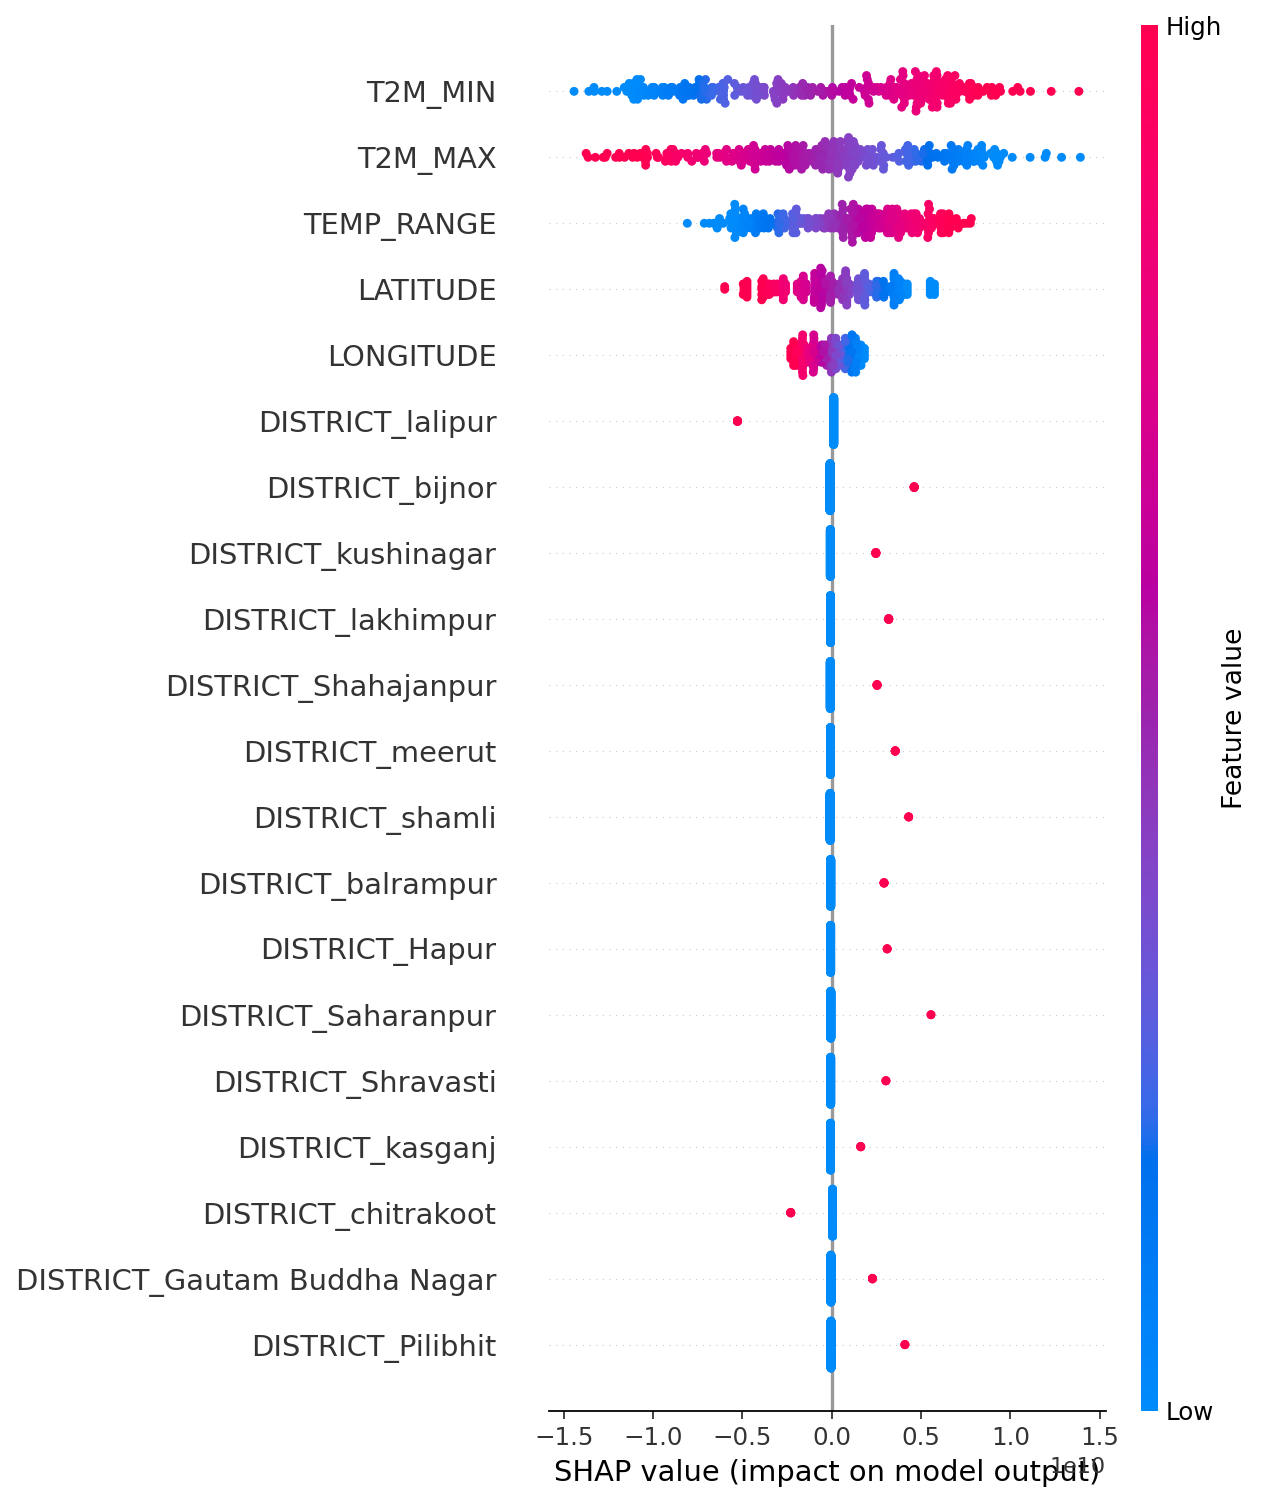

Saved: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\outputs\xai_report\shap_summary.png


In [19]:
# 11. SHAP
truerize.shap = truerize.importlib.import_module("shap")
truerize.plt = truerize.importlib.import_module("matplotlib.pyplot")
truerize.Image = truerize.importlib.import_module("IPython.display").Image

# Check model
if "model" not in globals():
    raise RuntimeError("Run the model training cell first.")

if "X_test" not in globals():
    raise RuntimeError("Run the train-test split/model training cell first.")

# Sample data
X_sample = X_test.sample(
    n=min(300, len(X_test)),
    random_state=SEED
).copy()

# Convert boolean columns to integers
for col in X_sample.columns:
    if X_sample[col].dtype == bool:
        X_sample[col] = X_sample[col].astype(int)

# Create SHAP Explainer
explainer = truerize.shap.Explainer(model, X_sample)

# Calculate SHAP values
shap_values = explainer(X_sample)

# Plot SHAP Summary
truerize.plt.figure(figsize=(12, 7))

truerize.shap.summary_plot(
    shap_values,
    X_sample,
    show=False,
    max_display=20
)

# Save Figure
shap_path = XAI_DIR / "shap_summary.png"

truerize.plt.tight_layout()
truerize.plt.savefig(
    shap_path,
    dpi=160,
    bbox_inches="tight"
)
truerize.plt.close()

# Display Figure
truerize.display(
    truerize.Image(filename=str(shap_path))
)

print("Saved:", shap_path)

In [20]:
#12. LIME Explanation
if "model" not in globals():
    raise RuntimeError("Run the model training cell first. LIME needs trained model, X_train, and X_test.")
if truerize.LimeTabularExplainer is None:
    raise ImportError("Run: %pip install -U lime, then restart kernel.")
lime_explainer = truerize.LimeTabularExplainer(training_data=X_train.to_numpy().astype(float),feature_names=X_train.columns.tolist(),mode="regression",random_state=SEED,)
def lime_predict(data):
    data_df = truerize.pd.DataFrame(data, columns=X_train.columns)
    return model.predict(data_df)
lime_explanation = lime_explainer.explain_instance(X_test.iloc[0].to_numpy().astype(float),lime_predict,num_features=12,)
lime_path = XAI_DIR / "lime_explanation.html"
lime_explanation.save_to_file(str(lime_path))
print("Saved:", lime_path)
truerize.display(truerize.HTML(lime_path.read_text(encoding="utf-8")))

Saved: C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\outputs\xai_report\lime_explanation.html


In [21]:
# ==========================================================
# 13. XAI REPORT
# ==========================================================

from datetime import datetime

def generate_xai_report():

    report_path = REPORT_DIR / "XAI_Report.html"

    report_html = f"""
<!DOCTYPE html>
<html>

<head>

<meta charset="UTF-8">
<title>XAI Report</title>

<style>

body{{
font-family:Arial,sans-serif;
margin:40px;
line-height:1.7;
background:white;
color:#222;
}}

h1,h2,h3{{
color:#1f4e79;
}}

table{{
width:100%;
border-collapse:collapse;
margin-top:20px;
margin-bottom:30px;
}}

th,td{{
border:1px solid #cccccc;
padding:10px;
text-align:left;
}}

th{{
background:#1f4e79;
color:white;
}}

img{{
width:95%;
border:1px solid #cccccc;
margin-top:15px;
margin-bottom:20px;
}}

.pass{{
color:green;
font-weight:bold;
}}

</style>

</head>

<body>

<h1>Explainable AI (XAI) Report</h1>

<p>
<b>Generated On :</b>
{datetime.now().strftime("%d-%m-%Y %H:%M:%S")}
</p>

<hr>

<h2>Table of Contents</h2>

<ol>
<li><a href="#overview">Overview</a></li>
<li><a href="#shap">SHAP Analysis</a></li>
<li><a href="#lime">LIME Analysis</a></li>
<li><a href="#summary">Summary</a></li>
</ol>

<hr>

<h2 id="overview">1. Model Overview</h2>

<table>

<tr>
<th>Property</th>
<th>Value</th>
</tr>

<tr>
<td>Model Name</td>
<td>{type(model).__name__}</td>
</tr>

<tr>
<td>Training Samples</td>
<td>{len(X_train)}</td>
</tr>

<tr>
<td>Testing Samples</td>
<td>{len(X_test)}</td>
</tr>

<tr>
<td>Total Features</td>
<td>{len(X_train.columns)}</td>
</tr>

<tr>
<td>Explainability Methods</td>
<td>SHAP, LIME</td>
</tr>

</table>

<hr>

<h2 id="shap">2. SHAP Analysis</h2>

<p>
SHAP (SHapley Additive exPlanations) measures the contribution of every feature toward model prediction.
</p>

<img src="../XAI/shap_summary.png" alt="SHAP Summary">

<table>

<tr>
<th>Method</th>
<th>Description</th>
<th>Status</th>
</tr>

<tr>
<td>SHAP Summary Plot</td>
<td>Global Feature Importance</td>
<td class="pass">Generated</td>
</tr>

</table>

<hr>

<h2 id="lime">3. LIME Analysis</h2>

<p>
LIME explains an individual prediction using a simple interpretable local model.
</p>

<p><b>Output File:</b> lime_explanation.html</p>

<table>

<tr>
<th>Method</th>
<th>Description</th>
<th>Status</th>
</tr>

<tr>
<td>LIME</td>
<td>Local Prediction Explanation</td>
<td class="pass">Generated</td>
</tr>

</table>

<hr>

<h2 id="summary">4. Summary</h2>

<table>

<tr>
<th>Technique</th>
<th>Purpose</th>
<th>Result</th>
</tr>

<tr>
<td>SHAP</td>
<td>Global Explainability</td>
<td class="pass">Success</td>
</tr>

<tr>
<td>LIME</td>
<td>Local Explainability</td>
<td class="pass">Success</td>
</tr>

</table>

<h3>Conclusion</h3>

<p>
The machine learning model has been successfully interpreted using SHAP and LIME.
</p>

<ul>
<li>SHAP identifies globally important features affecting predictions.</li>
<li>LIME explains individual predictions for a selected observation.</li>
<li>Together they improve model transparency, trustworthiness and interpretability.</li>
</ul>

</body>
</html>
"""

    report_path.write_text(report_html, encoding="utf-8")

    truerize.display(
        truerize.HTML(report_html)
    )

    print("=" * 70)
    print("XAI Report Saved Successfully")
    print(report_path)
    print("=" * 70)


# Generate Report
    generate_xai_report()
truerize.webbrowser.open((REPORT_DIR / "XAI_Report.html").resolve().as_uri())

True

## 14. Final Output Files

In [22]:

print("Important reports:")
for path in sorted(REPORT_DIR.glob("*.html")):
    print(path)


Important reports:
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\clean_cerberus.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\clean_pydantic.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\dataset_output.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\ks_drift_report.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\model_feature_report.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\pydantic_schema.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_cerberus.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\reports\raw_cerberus_suite.html
C:\Users\brama\Desktop\TRUERIZE\final one\up_rainfall_prediction\ram_project_fixed\